In [1]:
import sqlite3
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

## Connect to SQL Database

I've now added in the new tables containig the user's playlists and tracks.

In [2]:
# Connect to SQLite database
conn = sqlite3.connect("spotify_dataset.db")
cursor = conn.cursor()

# List all tables in the database
cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")

# Fetch and print table names
tables = cursor.fetchall()
print("Tables in database:", tables)

Tables in database: [('spotify_tracks',), ('user_playlists',), ('user_tracks',)]


In [3]:
# Load dataset from SQLite
with sqlite3.connect("spotify_dataset.db") as conn:
    df_spotify_tracks = pd.read_sql_query("SELECT * FROM spotify_tracks;", conn)
    df_user_playlists = pd.read_sql_query("SELECT * FROM user_playlists;", conn)
    df_user_tracks = pd.read_sql_query("SELECT * FROM user_tracks;", conn)

In [4]:
"""Use left join in SQL to combine user_tracks and user_playlists."""

cmd = """SELECT P.id, P.name, P.owner_id, P.owner_display_name, T.playlist_id, T.track_id, T.track_explicit, T.track_album_id, T.track_artists, T.track_duration_ms, T.track_href, T.track_name, T.track_popularity
FROM user_tracks T 
LEFT JOIN user_playlists P 
ON T.playlist_id = P.id"""

with sqlite3.connect("spotify_dataset.db") as conn:
    df_users_PandT = pd.read_sql_query(cmd, conn)
df_users_PandT.head()

,id,name,owner_id,owner_display_name,playlist_id,track_id,track_explicit,track_album_id,track_artists,track_duration_ms,track_href,track_name,track_popularity
0,6csfOWUiqHqZCbKi7oiqu9,August 10,skeletongurlgame,Ava.jts,6csfOWUiqHqZCbKi7oiqu9,0yOf4dgkVq8jbB2zxVK8Zj,0.0,02zGqoK00H1Rx5T5A9dUXI,"[{""external_urls"": {""spotify"": ""https://open.s...",178000.0,https://api.spotify.com/v1/tracks/0yOf4dgkVq8j...,August 10,80.0
1,6csfOWUiqHqZCbKi7oiqu9,August 10,skeletongurlgame,Ava.jts,6csfOWUiqHqZCbKi7oiqu9,0yOf4dgkVq8jbB2zxVK8Zj,0.0,02zGqoK00H1Rx5T5A9dUXI,"[{""external_urls"": {""spotify"": ""https://open.s...",178000.0,https://api.spotify.com/v1/tracks/0yOf4dgkVq8j...,August 10,80.0
2,6csfOWUiqHqZCbKi7oiqu9,August 10,skeletongurlgame,Ava.jts,6csfOWUiqHqZCbKi7oiqu9,0yOf4dgkVq8jbB2zxVK8Zj,0.0,02zGqoK00H1Rx5T5A9dUXI,"[{""external_urls"": {""spotify"": ""https://open.s...",178000.0,https://api.spotify.com/v1/tracks/0yOf4dgkVq8j...,August 10,80.0
3,6csfOWUiqHqZCbKi7oiqu9,August 10,skeletongurlgame,Ava.jts,6csfOWUiqHqZCbKi7oiqu9,0yOf4dgkVq8jbB2zxVK8Zj,0.0,02zGqoK00H1Rx5T5A9dUXI,"[{""external_urls"": {""spotify"": ""https://open.s...",178000.0,https://api.spotify.com/v1/tracks/0yOf4dgkVq8j...,August 10,80.0
4,6csfOWUiqHqZCbKi7oiqu9,August 10,skeletongurlgame,Ava.jts,6csfOWUiqHqZCbKi7oiqu9,0yOf4dgkVq8jbB2zxVK8Zj,0.0,02zGqoK00H1Rx5T5A9dUXI,"[{""external_urls"": {""spotify"": ""https://open.s...",178000.0,https://api.spotify.com/v1/tracks/0yOf4dgkVq8j...,August 10,80.0


In [5]:
df_spotify_tracks.head()

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,0,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,0,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,0,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,0,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,0,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [6]:
df_user_playlists.head()

,id,href,description,name,owner_id,owner_display_name,tracks_href,username
0,6csfOWUiqHqZCbKi7oiqu9,https://api.spotify.com/v1/playlists/6csfOWUiq...,Playlist of similar songs based on August 10 b...,August 10,skeletongurlgame,Ava.jts,https://api.spotify.com/v1/playlists/6csfOWUiq...,Ava.jts
1,1rHNyjILyZMYPqtUBrK6aa,https://api.spotify.com/v1/playlists/1rHNyjILy...,,Another Indie Playlist,skeletongurlgame,Ava.jts,https://api.spotify.com/v1/playlists/1rHNyjILy...,Ava.jts
2,4VrgDdNjljYe5f9ftLooXd,https://api.spotify.com/v1/playlists/4VrgDdNjl...,Playlist of similar songs based on Inside Out ...,Sad Sad Sad,skeletongurlgame,Ava.jts,https://api.spotify.com/v1/playlists/4VrgDdNjl...,Ava.jts
3,1yI15ngEZ2Yb5OKY409sQ3,https://api.spotify.com/v1/playlists/1yI15ngEZ...,This playlist was created by https:&#x2F;&#x2F...,Need a beat and some sad lyrics,skeletongurlgame,Ava.jts,https://api.spotify.com/v1/playlists/1yI15ngEZ...,Ava.jts
4,0qANIO5qxX93MV2ZfAS30h,https://api.spotify.com/v1/playlists/0qANIO5qx...,Please add the top five songs from your 2024 S...,W25 NSDC Team Playlist!,315qy5gce4c4gy2gl4u27w2ru5wm,Izzy,https://api.spotify.com/v1/playlists/0qANIO5qx...,Ava.jts


In [7]:
df_user_tracks.head()

,playlist_id,track_id,track_explicit,track_album_id,track_artists,track_duration_ms,track_href,track_name,track_popularity,username
0,6csfOWUiqHqZCbKi7oiqu9,0yOf4dgkVq8jbB2zxVK8Zj,0.0,02zGqoK00H1Rx5T5A9dUXI,"[{""external_urls"": {""spotify"": ""https://open.s...",178000.0,https://api.spotify.com/v1/tracks/0yOf4dgkVq8j...,August 10,80.0,Ava.jts
1,6csfOWUiqHqZCbKi7oiqu9,4qCV8C8UNSY6acKaq9Q9A0,0.0,02zGqoK00H1Rx5T5A9dUXI,"[{""external_urls"": {""spotify"": ""https://open.s...",114000.0,https://api.spotify.com/v1/tracks/4qCV8C8UNSY6...,Sorry Story,33.0,Ava.jts
2,6csfOWUiqHqZCbKi7oiqu9,4NUhcsz9E1LrBe8nXLZqzp,0.0,4p3eRdoK7W7z0tz8OWA3JM,"[{""external_urls"": {""spotify"": ""https://open.s...",152000.0,https://api.spotify.com/v1/tracks/4NUhcsz9E1Lr...,It Almost Worked,76.0,Ava.jts
3,6csfOWUiqHqZCbKi7oiqu9,37l31PrCNsg8baUjarNAi9,0.0,0YjOnBY0FRufcmNBTzWTgX,"[{""external_urls"": {""spotify"": ""https://open.s...",198213.0,https://api.spotify.com/v1/tracks/37l31PrCNsg8...,I Can't Handle Change,78.0,Ava.jts
4,6csfOWUiqHqZCbKi7oiqu9,3UGaLiDr0puYtIAhkDCD2J,0.0,2PWdXoJgmQC9VAQmLQLi1Q,"[{""external_urls"": {""spotify"": ""https://open.s...",96853.0,https://api.spotify.com/v1/tracks/3UGaLiDr0puY...,drain you,58.0,Ava.jts


I checked to see if there are any duplicate rows in each df, if so I removed them and reset the df indexing.

In [8]:
from music_rec import remove_duplicates
#I turned it into a function

In [9]:
df_spotify_tracks = remove_duplicates(df_spotify_tracks, ['track_name', 'artists'])

There are 32656 duplicate rows based on track_name and artists. Dropping them now...
After dropping duplicates, there are 81344 rows left.


In [10]:
df_user_playlists = remove_duplicates(df_user_playlists, ['name', 'description'])

There are 300 duplicate rows based on name and description. Dropping them now...
After dropping duplicates, there are 50 rows left.


In [11]:
df_user_tracks = remove_duplicates(df_user_tracks, ['track_name', 'track_popularity'])

There are 16249 duplicate rows based on track_name and track_popularity. Dropping them now...
After dropping duplicates, there are 2224 rows left.


In [12]:
df_users_PandT = remove_duplicates(df_users_PandT, ['track_name', 'track_popularity', 'playlist_id'])

There are 126748 duplicate rows based on track_name and track_popularity. Dropping them now...
After dropping duplicates, there are 2563 rows left.


Next I created a new df which contains all the user's songs that our kaggle dataset already has, so we can use those song metrics.

In [13]:
#I turned this into a function too, and it includes remove_duplicates within it
from music_rec import prep_dfs
user_df, df_spotify_tracks = prep_dfs(df_spotify_tracks, df_user_tracks)
user_df

There are 0 duplicate rows based on track_name and artists.
There are 0 duplicate rows based on track_name and track_popularity.
length of user_df: 0


,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,...,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre,track_genre_encoded
0,6LUGvXEAK8WxIBYK43uoTb,The Smiths,Louder Than Bombs,Back to the Old House - 2011 Remaster,74,186626,0,0.626,0.488,2,...,1,0.0253,0.010200,0.000188,0.1410,0.404,104.130,3,punk-rock,27
1,0TZejo18HlJ86OrWNsXKnw,Strawberry Guy,Mrs Magic,Mrs Magic,77,208500,0,0.471,0.634,8,...,1,0.0310,0.159000,0.365000,0.3740,0.366,132.542,4,indie-pop,19
2,3jfZ9M23l0L7RxzYMTgBTv,Joy Again,Looking Out for You,Looking Out for You,80,179499,0,0.682,0.900,9,...,1,0.0874,0.088400,0.063000,0.0685,0.937,100.721,4,garage,15
3,0z1o5L7HJx562xZSATcIpY,Radiohead,OK Computer,Exit Music (For A Film),73,267186,0,0.293,0.276,4,...,0,0.0349,0.224000,0.122000,0.1670,0.195,121.603,4,alt-rock,1
4,14N3tALR3Mhf7UHpJRKk4L,The Front Bottoms,Talon Of The Hawk,Twin Size Mattress,71,264676,0,0.325,0.867,4,...,1,0.0809,0.005480,0.000004,0.1030,0.336,144.866,4,emo,13
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
201,5BbAbnlNW3JfGGwG0Hkei9,Otaku;LoFi Waiter,Anime Lofi Vol. 1,Silhouette (Naruto Shippuden),53,113921,0,0.760,0.322,2,...,1,0.0485,0.568000,0.927000,0.0855,0.184,160.028,4,anime,4
202,38gqeaSyRwk64S9Xf1xDzD,Otaku,Anime Lofi Vol. 1,The Hero (One Punch Man),52,101151,0,0.744,0.158,10,...,0,0.0430,0.231000,0.852000,0.1040,0.112,140.190,4,anime,4
203,1ovr8NrhUZWz64ZM1bfbzG,Otaku,Anime Lofi Vol. 2,Sign (Naruto Shippuden),51,117203,0,0.604,0.203,0,...,0,0.0439,0.502000,0.837000,0.1350,0.454,79.998,4,anime,4
204,0hmELN1LsoFyKCE4AqrTFN,Otaku;LoFi Waiter,Ghibli Lofi,The Girl Who Fell from the Sky,58,115216,0,0.635,0.307,0,...,0,0.0446,0.676000,0.904000,0.0928,0.408,150.456,4,anime,4


In [14]:
df_users_PandT.head()

,id,name,owner_id,owner_display_name,playlist_id,track_id,track_explicit,track_album_id,track_artists,track_duration_ms,track_href,track_name,track_popularity
0,6csfOWUiqHqZCbKi7oiqu9,August 10,skeletongurlgame,Ava.jts,6csfOWUiqHqZCbKi7oiqu9,0yOf4dgkVq8jbB2zxVK8Zj,0.0,02zGqoK00H1Rx5T5A9dUXI,"[{""external_urls"": {""spotify"": ""https://open.s...",178000.0,https://api.spotify.com/v1/tracks/0yOf4dgkVq8j...,August 10,80.0
1,6csfOWUiqHqZCbKi7oiqu9,August 10,skeletongurlgame,Ava.jts,6csfOWUiqHqZCbKi7oiqu9,4qCV8C8UNSY6acKaq9Q9A0,0.0,02zGqoK00H1Rx5T5A9dUXI,"[{""external_urls"": {""spotify"": ""https://open.s...",114000.0,https://api.spotify.com/v1/tracks/4qCV8C8UNSY6...,Sorry Story,33.0
2,6csfOWUiqHqZCbKi7oiqu9,August 10,skeletongurlgame,Ava.jts,6csfOWUiqHqZCbKi7oiqu9,4NUhcsz9E1LrBe8nXLZqzp,0.0,4p3eRdoK7W7z0tz8OWA3JM,"[{""external_urls"": {""spotify"": ""https://open.s...",152000.0,https://api.spotify.com/v1/tracks/4NUhcsz9E1Lr...,It Almost Worked,76.0
3,6csfOWUiqHqZCbKi7oiqu9,August 10,skeletongurlgame,Ava.jts,6csfOWUiqHqZCbKi7oiqu9,37l31PrCNsg8baUjarNAi9,0.0,0YjOnBY0FRufcmNBTzWTgX,"[{""external_urls"": {""spotify"": ""https://open.s...",198213.0,https://api.spotify.com/v1/tracks/37l31PrCNsg8...,I Can't Handle Change,78.0
4,6csfOWUiqHqZCbKi7oiqu9,August 10,skeletongurlgame,Ava.jts,6csfOWUiqHqZCbKi7oiqu9,3UGaLiDr0puYtIAhkDCD2J,0.0,2PWdXoJgmQC9VAQmLQLi1Q,"[{""external_urls"": {""spotify"": ""https://open.s...",96853.0,https://api.spotify.com/v1/tracks/3UGaLiDr0puY...,drain you,58.0


I want to now filter `df_users_PandT` to only contain songs found in `user_df`. Can't use `prep_dfs()` since it outputs df without the playlist name/id column, which we need. Can turn this into function but unsure when we will use this code again.

In [15]:
# Extract column 'track_id' as a list
track_ids = user_df['track_id'].tolist()

# Filter the DataFrame
df_users_PandT = df_users_PandT[df_users_PandT['track_id'].isin(track_ids)]

# Rest the index of rows
df_users_PandT = df_users_PandT.reset_index(drop=True)

df_users_PandT.head()


,id,name,owner_id,owner_display_name,playlist_id,track_id,track_explicit,track_album_id,track_artists,track_duration_ms,track_href,track_name,track_popularity
0,6csfOWUiqHqZCbKi7oiqu9,August 10,skeletongurlgame,Ava.jts,6csfOWUiqHqZCbKi7oiqu9,6LUGvXEAK8WxIBYK43uoTb,0.0,45StnugV9WQMQwk4rRoTy8,"[{""external_urls"": {""spotify"": ""https://open.s...",186626.0,https://api.spotify.com/v1/tracks/6LUGvXEAK8Wx...,Back to the Old House - 2011 Remaster,78.0
1,6csfOWUiqHqZCbKi7oiqu9,August 10,skeletongurlgame,Ava.jts,6csfOWUiqHqZCbKi7oiqu9,0TZejo18HlJ86OrWNsXKnw,0.0,3Oovjf1PZOryLQSDKwjJzO,"[{""external_urls"": {""spotify"": ""https://open.s...",208500.0,https://api.spotify.com/v1/tracks/0TZejo18HlJ8...,Mrs Magic,79.0
2,6csfOWUiqHqZCbKi7oiqu9,August 10,skeletongurlgame,Ava.jts,6csfOWUiqHqZCbKi7oiqu9,3jfZ9M23l0L7RxzYMTgBTv,0.0,7slouenWhZDdDZibkS4nR3,"[{""external_urls"": {""spotify"": ""https://open.s...",179499.0,https://api.spotify.com/v1/tracks/3jfZ9M23l0L7...,Looking Out for You,77.0
3,6csfOWUiqHqZCbKi7oiqu9,August 10,skeletongurlgame,Ava.jts,6csfOWUiqHqZCbKi7oiqu9,0z1o5L7HJx562xZSATcIpY,0.0,6dVIqQ8qmQ5GBnJ9shOYGE,"[{""external_urls"": {""spotify"": ""https://open.s...",267186.0,https://api.spotify.com/v1/tracks/0z1o5L7HJx56...,Exit Music (For A Film),75.0
4,6csfOWUiqHqZCbKi7oiqu9,August 10,skeletongurlgame,Ava.jts,6csfOWUiqHqZCbKi7oiqu9,14N3tALR3Mhf7UHpJRKk4L,0.0,1Xz5zrDqXetBm5HwNGSqPs,"[{""external_urls"": {""spotify"": ""https://open.s...",264676.0,https://api.spotify.com/v1/tracks/14N3tALR3Mhf...,Twin Size Mattress,69.0


# Refine Recommendation System
Want to get a specfied playlist from `df_user_PandT`, then recommend 5 songs based on this specific playlist using our recommender system. This is an existing feature in Spotify, so we want to ensure our recommendation system is just as accurate.

In [16]:
df_users_PandT.head(10)

,id,name,owner_id,owner_display_name,playlist_id,track_id,track_explicit,track_album_id,track_artists,track_duration_ms,track_href,track_name,track_popularity
0,6csfOWUiqHqZCbKi7oiqu9,August 10,skeletongurlgame,Ava.jts,6csfOWUiqHqZCbKi7oiqu9,6LUGvXEAK8WxIBYK43uoTb,0.0,45StnugV9WQMQwk4rRoTy8,"[{""external_urls"": {""spotify"": ""https://open.s...",186626.0,https://api.spotify.com/v1/tracks/6LUGvXEAK8Wx...,Back to the Old House - 2011 Remaster,78.0
1,6csfOWUiqHqZCbKi7oiqu9,August 10,skeletongurlgame,Ava.jts,6csfOWUiqHqZCbKi7oiqu9,0TZejo18HlJ86OrWNsXKnw,0.0,3Oovjf1PZOryLQSDKwjJzO,"[{""external_urls"": {""spotify"": ""https://open.s...",208500.0,https://api.spotify.com/v1/tracks/0TZejo18HlJ8...,Mrs Magic,79.0
2,6csfOWUiqHqZCbKi7oiqu9,August 10,skeletongurlgame,Ava.jts,6csfOWUiqHqZCbKi7oiqu9,3jfZ9M23l0L7RxzYMTgBTv,0.0,7slouenWhZDdDZibkS4nR3,"[{""external_urls"": {""spotify"": ""https://open.s...",179499.0,https://api.spotify.com/v1/tracks/3jfZ9M23l0L7...,Looking Out for You,77.0
3,6csfOWUiqHqZCbKi7oiqu9,August 10,skeletongurlgame,Ava.jts,6csfOWUiqHqZCbKi7oiqu9,0z1o5L7HJx562xZSATcIpY,0.0,6dVIqQ8qmQ5GBnJ9shOYGE,"[{""external_urls"": {""spotify"": ""https://open.s...",267186.0,https://api.spotify.com/v1/tracks/0z1o5L7HJx56...,Exit Music (For A Film),75.0
4,6csfOWUiqHqZCbKi7oiqu9,August 10,skeletongurlgame,Ava.jts,6csfOWUiqHqZCbKi7oiqu9,14N3tALR3Mhf7UHpJRKk4L,0.0,1Xz5zrDqXetBm5HwNGSqPs,"[{""external_urls"": {""spotify"": ""https://open.s...",264676.0,https://api.spotify.com/v1/tracks/14N3tALR3Mhf...,Twin Size Mattress,69.0
5,6csfOWUiqHqZCbKi7oiqu9,August 10,skeletongurlgame,Ava.jts,6csfOWUiqHqZCbKi7oiqu9,2enPRFda84VE2wtI8c86Uf,0.0,6WnfWrfsfu7T9TXbHIFHX9,"[{""external_urls"": {""spotify"": ""https://open.s...",223746.0,https://api.spotify.com/v1/tracks/2enPRFda84VE...,Always Forever,79.0
6,6csfOWUiqHqZCbKi7oiqu9,August 10,skeletongurlgame,Ava.jts,6csfOWUiqHqZCbKi7oiqu9,1KIJclzEbNhSVw8tiHPWwE,0.0,54lNPJ6xq2QXwG6jLEIf6C,"[{""external_urls"": {""spotify"": ""https://open.s...",189160.0,https://api.spotify.com/v1/tracks/1KIJclzEbNhS...,Young,78.0
7,1rHNyjILyZMYPqtUBrK6aa,Another Indie Playlist,skeletongurlgame,Ava.jts,1rHNyjILyZMYPqtUBrK6aa,40iocOzytrqaRn5RbGPDNp,0.0,4uNgt1uQs6wZRm4giB3shX,"[{""external_urls"": {""spotify"": ""https://open.s...",208453.0,https://api.spotify.com/v1/tracks/40iocOzytrqa...,Cherry Flavoured,63.0
8,1rHNyjILyZMYPqtUBrK6aa,Another Indie Playlist,skeletongurlgame,Ava.jts,1rHNyjILyZMYPqtUBrK6aa,2RJfK2pOvGpnxC255YOy5k,0.0,1c9Sx7XdXuMptGyfCB6hHs,"[{""external_urls"": {""spotify"": ""https://open.s...",212853.0,https://api.spotify.com/v1/tracks/2RJfK2pOvGpn...,Rose-Colored Boy,65.0
9,1rHNyjILyZMYPqtUBrK6aa,Another Indie Playlist,skeletongurlgame,Ava.jts,1rHNyjILyZMYPqtUBrK6aa,0w5Bdu51Ka25Pf3hojsKHh,0.0,1c9Sx7XdXuMptGyfCB6hHs,"[{""external_urls"": {""spotify"": ""https://open.s...",182693.0,https://api.spotify.com/v1/tracks/0w5Bdu51Ka25...,Hard Times,79.0


In [17]:
from music_rec import playlist_song_recs

song_recs = playlist_song_recs(df_users_PandT, df_spotify_tracks, "Brat")
song_recs

c:\Users\avajt\Projects\pic16b_project\music_rec.py:222: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  requested_playlist_features['track_genre_encoded'] = label_encoder.transform(requested_playlist_features['track_genre'])


Top genres in the requested playlist:
track_genre
indie-pop    7
electro      4
soul         1
Name: count, dtype: int64


,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,...,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre,track_genre_encoded
25459,18uwL0vNUanqZH0ro2QcOP,Jeremy Zucker,"summer,",comethru,79,181613,0,0.795,0.178,0,...,1,0.0574,0.6070,0.000000,0.6230,0.608,93.982,4,electro,31
44399,47UFoOuvrkt4khE7c5aap6,Sub Urban,Cradles,Cradles,76,209829,0,0.537,0.586,6,...,1,0.3140,0.2650,0.000070,0.1750,0.624,79.056,4,indie-pop,57
25460,4IQqOlTZpfjnSTOArpZX5j,Farasat Anees;Slick Trick;Toshi,OFIVE1,BIBA,66,216216,0,0.758,0.573,6,...,0,0.0428,0.0888,0.000677,0.0834,0.284,110.983,4,electro,31
44395,6CDzDgIUqeDY5g8ujExx2f,Glass Animals,Heat Waves,Heat Waves,85,238805,0,0.761,0.525,11,...,1,0.0944,0.4400,0.000007,0.0921,0.531,80.870,4,indie-pop,57
25461,4DpNNXFMMxQEKl7r0ykkWA,Melanie Martinez,Cry Baby (Deluxe Edition),Play Date,79,179867,1,0.680,0.729,5,...,1,0.0475,0.6120,0.000000,0.2240,0.446,123.970,4,electro,31


## Get Playlist Recommendation

In [18]:
# Select relevant numerical features from our user's songs
features = ['danceability', 'energy', 'tempo', 'speechiness', 'acousticness', 'instrumentalness', 'valence', 'loudness', ]
df_users_filtered = user_df[features]

In [19]:
# Split data into train and test sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(df_users_filtered, df_users_filtered, test_size=0.2, random_state=42)

Want to fine tune the KNN model to ensure we are choosing the best parameters.

In [20]:
# Find the best k value
from music_rec import tune_knn

best_k, scores = tune_knn(X_train, X_test)
print(f"Optimal number of neighbors: {best_k}")

Optimal number of neighbors: 1


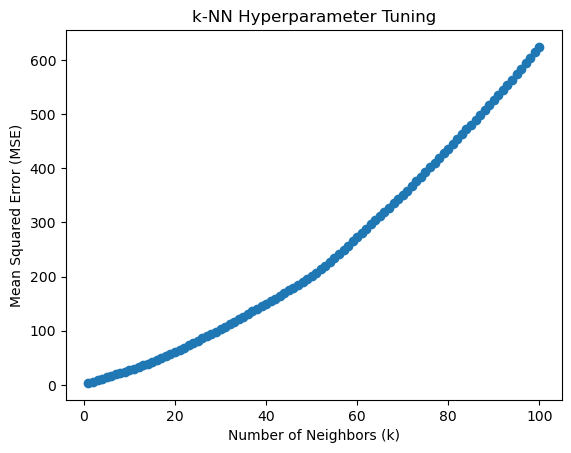

In [21]:
# Plot results
import matplotlib.pyplot as plt

k_values, mse_scores = zip(*scores)
plt.plot(k_values, mse_scores, marker='o', linestyle='-')
plt.xlabel("Number of Neighbors (k)")
plt.ylabel("Mean Squared Error (MSE)")
plt.title("k-NN Hyperparameter Tuning")
plt.show()

There are possible signs of overfitting since the best n_neighbor is 1, and the MSE scores are so accurate.

In [22]:
# Fit k-NN model with 7 features
knn = NearestNeighbors(n_neighbors=best_k, metric='euclidean')
knn.fit(df_users_filtered)

NearestNeighbors(metric='euclidean', n_neighbors=1)

We can now create a playlist based on the user's overall tracks. 

In [23]:
def recommend_songs(df, genre, n=30, random_state=42):
    """
    Generate a personalized playlist of `n` songs from a specific genre based on the user's preferences.

    Args:
        df: The user's listening history with audio features.
        genre: The genre of songs to recommend.
        n: The number of songs to recommend (default is 5).
        random_state: Seed for reproducibility (default is 42).

    Returns:
        random_recommendations: A DataFrame containing the recommended songs.
    """
    # Filter the Spotify dataset to include only songs from the specified genre
    genre_tracks = df_spotify_tracks[df_spotify_tracks['track_genre'].str.lower() == genre.lower()]

    # Check if there are enough songs in the specified genre
    if len(genre_tracks) < n:
        raise ValueError(f"Not enough songs in the '{genre}' genre. Only {len(genre_tracks)} songs available.")

    # Select relevant features for the KNN model
    features = ['danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness',
                'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo']

    # Prepare the feature matrix for the user's listening history
    X_user = user_df[features]

    # Train the KNN model on the user's data
    # Standardize the features
    scaler = StandardScaler()
    X_user_scaled = scaler.fit_transform(X_user)

    # Ensure `n` does not exceed the number of available songs in the dataset
    max_neighbors = min(n, len(X_user_scaled))

    # Train the KNN model on the user's features
    knn = NearestNeighbors(n_neighbors=max_neighbors, metric='euclidean')  # Use Euclidean distance
    knn.fit(X_user_scaled)

    # Prepare the feature matrix for the genre-specific songs
    X_genre = genre_tracks[features]
    X_genre_scaled = scaler.transform(X_genre)

    # Find the nearest neighbors (most similar songs) in the genre-specific dataset
    distances, indices = knn.kneighbors(X_genre_scaled)

    # Flatten the indices array to get a list of all recommended song indices
    recommended_song_indices = indices.flatten()

    # Ensure indices are within the valid range of the genre_tracks DataFrame
    valid_indices = [idx for idx in recommended_song_indices if idx < len(genre_tracks)]

    if not valid_indices:
        raise ValueError("No valid recommendations found. Please check the input data.")

    # Get the recommended songs
    recommended_songs = genre_tracks.iloc[valid_indices].drop_duplicates(subset=['track_id']).head(n)

    # Randomly select `n` songs from the recommendations
    random_recommendations = recommended_songs.sample(n=n, random_state=random_state)

    # Display the recommended songs
    return random_recommendations

In [24]:

recommendations = recommend_songs(user_df, genre='electro', n=15)
recommendations

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,...,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre,track_genre_encoded
25624,4vsAUbPb6q9FpC4AGBFdVh,Loote,lost,tomorrow tonight,65,202600,0,0.320,0.500,3,...,1,0.0994,0.1340,0.000000,0.1080,0.142,91.361,4,electro,31
25545,4KA0TIfLXLFlmoRK94K2wf,Alec Benjamin,New Pop,Devil Doesn't Bargain,0,163613,0,0.448,0.606,3,...,1,0.0609,0.5770,0.000000,0.2170,0.483,121.150,4,electro,31
25499,4pTkDIlpFNoeWbahu8pVXW,Izzamuzzic;Julien Marchal,Shootout,Shootout,78,295308,0,0.663,0.578,2,...,1,0.0687,0.3120,0.906000,0.1090,0.553,86.986,4,electro,31
25556,2Foc5Q5nqNiosCNqttzHof,Daft Punk;Pharrell Williams;Nile Rodgers,Get Lucky (feat. Pharrell Williams & Nile Rodg...,Get Lucky (feat. Pharrell Williams & Nile Rodg...,82,248413,0,0.794,0.811,6,...,0,0.0380,0.0426,0.000001,0.1010,0.862,116.047,4,electro,31
25500,1iQDltZqI7BXnHrFy4Qo1k,SHAED;ZAYN,Trampoline (with ZAYN),Trampoline (with ZAYN),69,184280,0,0.619,0.459,7,...,0,0.0334,0.5600,0.000000,0.1370,0.498,126.803,4,electro,31
25481,6qrifdo7QINdPQr80IelGi,Rovalio;Abdul Hannan,Iraaday,Iraaday,66,133305,0,0.737,0.458,6,...,1,0.0317,0.6010,0.000007,0.1380,0.456,89.993,4,electro,31
25631,18Eu9puOprFj4acahSyF1d,Sickflip;Mismatched;Raitila Rajasthan,Mismatched: Season 2 (Music from the Netflix S...,Mehmaan,51,170400,0,0.367,0.518,11,...,1,0.4640,0.8140,0.071000,0.1600,0.530,98.240,4,electro,31
25602,2cGxRwrMyEAp8dEbuZaVv6,Daft Punk;Julian Casablancas,Random Access Memories,Instant Crush (feat. Julian Casablancas),76,337560,0,0.775,0.585,10,...,0,0.0271,0.0422,0.619000,0.0770,0.518,109.942,4,electro,31
25635,0ZnwzjB40zdTZrEwPvaRqG,Otnicka,Babel,Babel,60,198962,0,0.883,0.366,2,...,0,0.0706,0.1400,0.915000,0.1020,0.397,107.998,4,electro,31
25581,4QmaaHKCPL4YWW6L5AdQQs,Charli XCX,Gaming Songs 2022: Hard Mode,Vroom Vroom,0,193270,1,0.835,0.684,11,...,1,0.2390,0.1220,0.000000,0.0854,0.517,151.009,4,electro,31


In [25]:
from music_rec import recommend_songs
recommend_songs(user_df, df_spotify_tracks, genre = 'electro')

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,...,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre,track_genre_encoded
25637,0jllH0usRFD4LJkJnGK9Lf,Olivia O'Brien,Complicated,Complicated,71,189000,0,0.657,0.355,7,...,1,0.0714,0.6940,0.000427,0.1230,0.0808,74.990,4,electro,31
25579,1ZDzahk1OMKP9poJJ3VVpu,Charli XCX;Troye Sivan,Am I Ready - Pop Night Out,1999,3,189000,0,0.741,0.743,7,...,1,0.0328,0.0224,0.000001,0.2290,0.6580,124.014,4,electro,31
25569,49aoOZzUdoUoMBbfG0KEJw,Bazzi,Music for Rainy Days,Beautiful,0,178242,0,0.666,0.677,2,...,1,0.0326,0.2140,0.000000,0.0979,0.1780,100.014,4,electro,31
25603,0AUvWawuP0ibk4SQ3sIZjk,Ashnikko,Daisy,Daisy,71,146523,1,0.834,0.663,8,...,1,0.1330,0.2350,0.000000,0.3720,0.7740,121.876,4,electro,31
25481,6qrifdo7QINdPQr80IelGi,Rovalio;Abdul Hannan,Iraaday,Iraaday,66,133305,0,0.737,0.458,6,...,1,0.0317,0.6010,0.000007,0.1380,0.4560,89.993,4,electro,31
25624,4vsAUbPb6q9FpC4AGBFdVh,Loote,lost,tomorrow tonight,65,202600,0,0.320,0.500,3,...,1,0.0994,0.1340,0.000000,0.1080,0.1420,91.361,4,electro,31
25641,0PgYPBGqF6Wm5KFHQ81nq5,Jeremy Zucker;Bea Miller,comethru,comethru (with Bea Miller),65,181626,0,0.757,0.192,0,...,1,0.0515,0.5720,0.000000,0.6060,0.5950,94.024,4,electro,31
25516,1v8HKXubkw9fpYfOJdmAc7,Wisin & Yandel,Homecoming Latin Party,Pegao,0,234546,0,0.792,0.804,3,...,1,0.2590,0.5370,0.000000,0.3420,0.8070,96.041,4,electro,31
25504,0zqBZqm5czQ3A4EoSdKFHj,Alan Walker;Benjamin Ingrosso,World Of Walker,Man On The Moon,73,178625,0,0.668,0.816,4,...,0,0.0367,0.0557,0.000001,0.1970,0.5000,129.971,4,electro,31
25499,4pTkDIlpFNoeWbahu8pVXW,Izzamuzzic;Julien Marchal,Shootout,Shootout,78,295308,0,0.663,0.578,2,...,1,0.0687,0.3120,0.906000,0.1090,0.5530,86.986,4,electro,31
